In [136]:
print("=== RFM CUSTOMER SEGMENTATION PROJECT ===")
print("Files: Customer_Master_Data.csv + Customer_Transactions.csv")
print("Date: 2026-02-22 | Analyst: Tushar (Delhi)")
print("Tools: Pandas, Matplotlib, Seaborn")
print("="*60)

=== RFM CUSTOMER SEGMENTATION PROJECT ===
Files: Customer_Master_Data.csv + Customer_Transactions.csv
Date: 2026-02-22 | Analyst: Tushar (Delhi)
Tools: Pandas, Matplotlib, Seaborn


In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Data

In [138]:
#load Customer_Master_Data
df_customers = pd.read_csv("Customer_Master_Data.csv")
print("Customer Master shape:", df_customers.shape)
print("\nCustomer Master sample:")
print(df_customers.head(2))

Customer Master shape: (1000, 9)

Customer Master sample:
  CustomerID            Name              Email  Gender  Age     City  \
0  CUST10000  Onkar Bhargava    pkeer@yahoo.com    Male   54    Delhi   
1  CUST10001     Divit Kohli  mkalita@sarin.com  Female   48  Kolkata   

  MaritalStatus  NumChildren    JoinDate  
0      Divorced            0  2021-02-22  
1       Married            0  2023-12-06  


In [139]:
# Load Customer_Transaction
df_transactions = pd.read_csv("Customer_Transactions.csv")
print("Transaction shape:", df_transactions.shape)
print("\nTransactions sample:")
print(df_transactions.head(2))

Transaction shape: (23050, 3)

Transactions sample:
  CustomerID TransactionDate  TransactionAmount
0  CUST10771         7/31/23            2383.07
1  CUST10100         3/10/24             497.54


# Clean and Prepare

#### STEP 1 - Covert Dates to Datetime

In [140]:
df_customers["JoinDate"] = pd.to_datetime (df_customers["JoinDate"], errors="coerce")
df_transactions ["TransactionDate"] = pd.to_datetime(df_transactions["TransactionDate"],  format="%m/%d/%y", errors="coerce")
print(df_customers.head(2))
print(df_transactions.head(2))

  CustomerID            Name              Email  Gender  Age     City  \
0  CUST10000  Onkar Bhargava    pkeer@yahoo.com    Male   54    Delhi   
1  CUST10001     Divit Kohli  mkalita@sarin.com  Female   48  Kolkata   

  MaritalStatus  NumChildren   JoinDate  
0      Divorced            0 2021-02-22  
1       Married            0 2023-12-06  
  CustomerID TransactionDate  TransactionAmount
0  CUST10771      2023-07-31            2383.07
1  CUST10100      2024-03-10             497.54


In [141]:
print("\nDate conversion check:")
print("JoinDate sample:", df_customers["JoinDate"].head(2).tolist())
print("TransactionDate sample:", df_transactions["TransactionDate"].head(2).tolist())


Date conversion check:
JoinDate sample: [Timestamp('2021-02-22 00:00:00'), Timestamp('2023-12-06 00:00:00')]
TransactionDate sample: [Timestamp('2023-07-31 00:00:00'), Timestamp('2024-03-10 00:00:00')]


#### STEP 2 - Check for missing values 

In [142]:
print("\nMissing values:")
print("Customer Master:\n", df_customers.isnull().sum())
print("\nTransactions:\n", df_transactions.isnull().sum())


Missing values:
Customer Master:
 CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64

Transactions:
 CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64


#### STEP 3 - Finding unique Customer ID & Total Rows

In [143]:
print("Unique CustomerIDs:", df_customers["CustomerID"].nunique())
print("Total Rows:", len(df_customers))

Unique CustomerIDs: 1000
Total Rows: 1000


#### STEP 4 - Validate Customer IDs

In [144]:
invalid_ids = set(df_transactions["CustomerID"]) - set(df_customers["CustomerID"])
print(f"\nInvalid CustomerIDs: {len(invalid_ids)}")  # should be empty


Invalid CustomerIDs: 0


#### STEP 5 - Check Data Types

In [145]:
print(df_customers.dtypes)
print(df_transactions.dtypes)

CustomerID               object
Name                     object
Email                    object
Gender                   object
Age                       int64
City                     object
MaritalStatus            object
NumChildren               int64
JoinDate         datetime64[ns]
dtype: object
CustomerID                   object
TransactionDate      datetime64[ns]
TransactionAmount           float64
dtype: object


#### STEP 6 - Removing & Checking Duplicates

In [146]:
df_transactions.drop_duplicates(inplace=True)
df_customers.drop_duplicates(inplace=True)
print(f"Duplicates removed - Customers: {df_customers.shape}, Transactions: {df_transactions.shape}")

Duplicates removed - Customers: (1000, 9), Transactions: (23050, 3)


# Merge transactions with customer master data

In [147]:
df = df_transactions.merge(df_customers, on="CustomerID", how="left")
print(f"\nMerged data shape: {df.shape}")
df.head()


Merged data shape: (23050, 11)


,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,2023-07-31,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,2024-03-10,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2025-02-17,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03
3,CUST10987,2023-07-17,314.89,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18
4,CUST10831,2024-12-15,2543.19,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30


# Set Reference Date

In [148]:
today = df_transactions["TransactionDate"].max() + pd.Timedelta(days=1)
print(f"Reference Date for Recency: {today.date()}")

Reference Date for Recency: 2025-07-30


# Compute RFM Metrics

#### 1. Group transactions by customer

In [149]:
grouped = df_transactions.groupby("CustomerID")

#### 2. Calculate Recency

In [150]:
recency  = grouped["TransactionDate"].max().apply(lambda x: (today - x). days)

#### 3. Calculate Frequency

In [151]:
frequency = grouped["TransactionDate"].count()

#### 4. Calculate Monetary

In [152]:
monetary = grouped["TransactionAmount"].sum()

#### 5. Combine into one DataFrame

In [153]:
df_rfm = pd.DataFrame({"Recency": recency,"Frequency":frequency,"Monetary":monetary}).reset_index()
print("\nRFM Metrics sample:")
print(df_rfm.head())


RFM Metrics sample:
  CustomerID  Recency  Frequency  Monetary
0  CUST10000       13         23  21265.49
1  CUST10001       35         30  28654.31
2  CUST10002       18         24  23884.03
3  CUST10003       81         25  24206.03
4  CUST10004        8         19  25565.30


In [154]:
df_rfm.describe()

,Recency,Frequency,Monetary
count,1000.000000,1000.000000,1000.00000
mean,50.794000,23.050000,23053.19966
std,58.124418,4.810472,5622.44101
min,1.000000,6.000000,5052.69000
25%,13.000000,20.000000,18965.46250
50%,32.000000,23.000000,22969.82000
75%,69.000000,26.000000,26827.39250
max,524.000000,38.000000,44784.99000


# Assign RFM Metrics

In [155]:
# Recency: lower days = higher score
df_rfm["R_Score"] = pd.qcut(df_rfm["Recency"], 5, labels=[5,4,3,2,1]).astype(int)

# Frequency: higher count = higher score
df_rfm["F_Score"] = pd.qcut(df_rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)

# Monetary: higher spend = higher score
df_rfm["M_Score"] = pd.qcut(df_rfm["Monetary"], 5, labels=[1,2,3,4,5]).astype(int)

In [156]:
print(df_rfm.head(10))

  CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score
0  CUST10000       13         23  21265.49        4        3        2
1  CUST10001       35         30  28654.31        3        5        5
2  CUST10002       18         24  23884.03        4        3        3
3  CUST10003       81         25  24206.03        1        4        3
4  CUST10004        8         19  25565.30        5        1        4
5  CUST10005       24         29  29459.82        4        5        5
6  CUST10006       11         28  27922.36        5        5        5
7  CUST10007       86         15  14957.06        1        1        1
8  CUST10008        3         19  19479.25        5        1        2
9  CUST10009        7         25  22832.83        5        4        3


# Create Combined RFM Segment

In [157]:
df_rfm["RFM_Segment"] = (
    df_rfm["R_Score"].astype(str) +
    df_rfm["F_Score"].astype(str) +
    df_rfm["M_Score"].astype(str)
)

df_rfm["RFM_Score"] = (
    df_rfm[["R_Score","F_Score","M_Score"]].astype(int).sum(axis=1)
)
print("\nRFM Score sample:")
print(df_rfm[["CustomerID", "Recency", "Frequency", "Monetary", "RFM_Segment", "RFM_Score"]].head(10))


RFM Score sample:
  CustomerID  Recency  Frequency  Monetary RFM_Segment  RFM_Score
0  CUST10000       13         23  21265.49         432          9
1  CUST10001       35         30  28654.31         355         13
2  CUST10002       18         24  23884.03         433         10
3  CUST10003       81         25  24206.03         143          8
4  CUST10004        8         19  25565.30         514         10
5  CUST10005       24         29  29459.82         455         14
6  CUST10006       11         28  27922.36         555         15
7  CUST10007       86         15  14957.06         111          3
8  CUST10008        3         19  19479.25         512          8
9  CUST10009        7         25  22832.83         543         12


# Segmentation Function (Fixed: Proper string comparison)

In [158]:
def segment(row):
    if row["RFM_Segment"] == "555":
        return "Champions"
    elif row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Loyal Customers"
    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"
    elif row["RFM_Segment"] == "111":
        return "Lost Customers"
    else:
        return "Others"

df_rfm["Segment"] = df_rfm.apply(segment, axis=1)

In [159]:
print(df_rfm.head(10))

  CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0  CUST10000       13         23  21265.49        4        3        2   
1  CUST10001       35         30  28654.31        3        5        5   
2  CUST10002       18         24  23884.03        4        3        3   
3  CUST10003       81         25  24206.03        1        4        3   
4  CUST10004        8         19  25565.30        5        1        4   
5  CUST10005       24         29  29459.82        4        5        5   
6  CUST10006       11         28  27922.36        5        5        5   
7  CUST10007       86         15  14957.06        1        1        1   
8  CUST10008        3         19  19479.25        5        1        2   
9  CUST10009        7         25  22832.83        5        4        3   

  RFM_Segment  RFM_Score          Segment  
0         432          9           Others  
1         355         13           Others  
2         433         10           Others  
3         143       

In [160]:
print("\nSegment Distribution:")
print(df_rfm["Segment"].value_counts())


Segment Distribution:
Segment
Others             575
At Risk            228
Loyal Customers    130
Champions           37
Lost Customers      30
Name: count, dtype: int64


In [161]:
segment_revenue = df_rfm.merge(df_transactions.groupby("CustomerID")["TransactionAmount"].sum(), 
                              on="CustomerID", how="left").groupby("Segment")["TransactionAmount"].sum()
print("\nRevenue by Segment:")
print(segment_revenue.sort_values(ascending=False))


Revenue by Segment:
Segment
Others             12130514.80
At Risk             5832771.27
Loyal Customers     3475588.74
Champions           1156835.88
Lost Customers       457488.97
Name: TransactionAmount, dtype: float64


# Visualizations

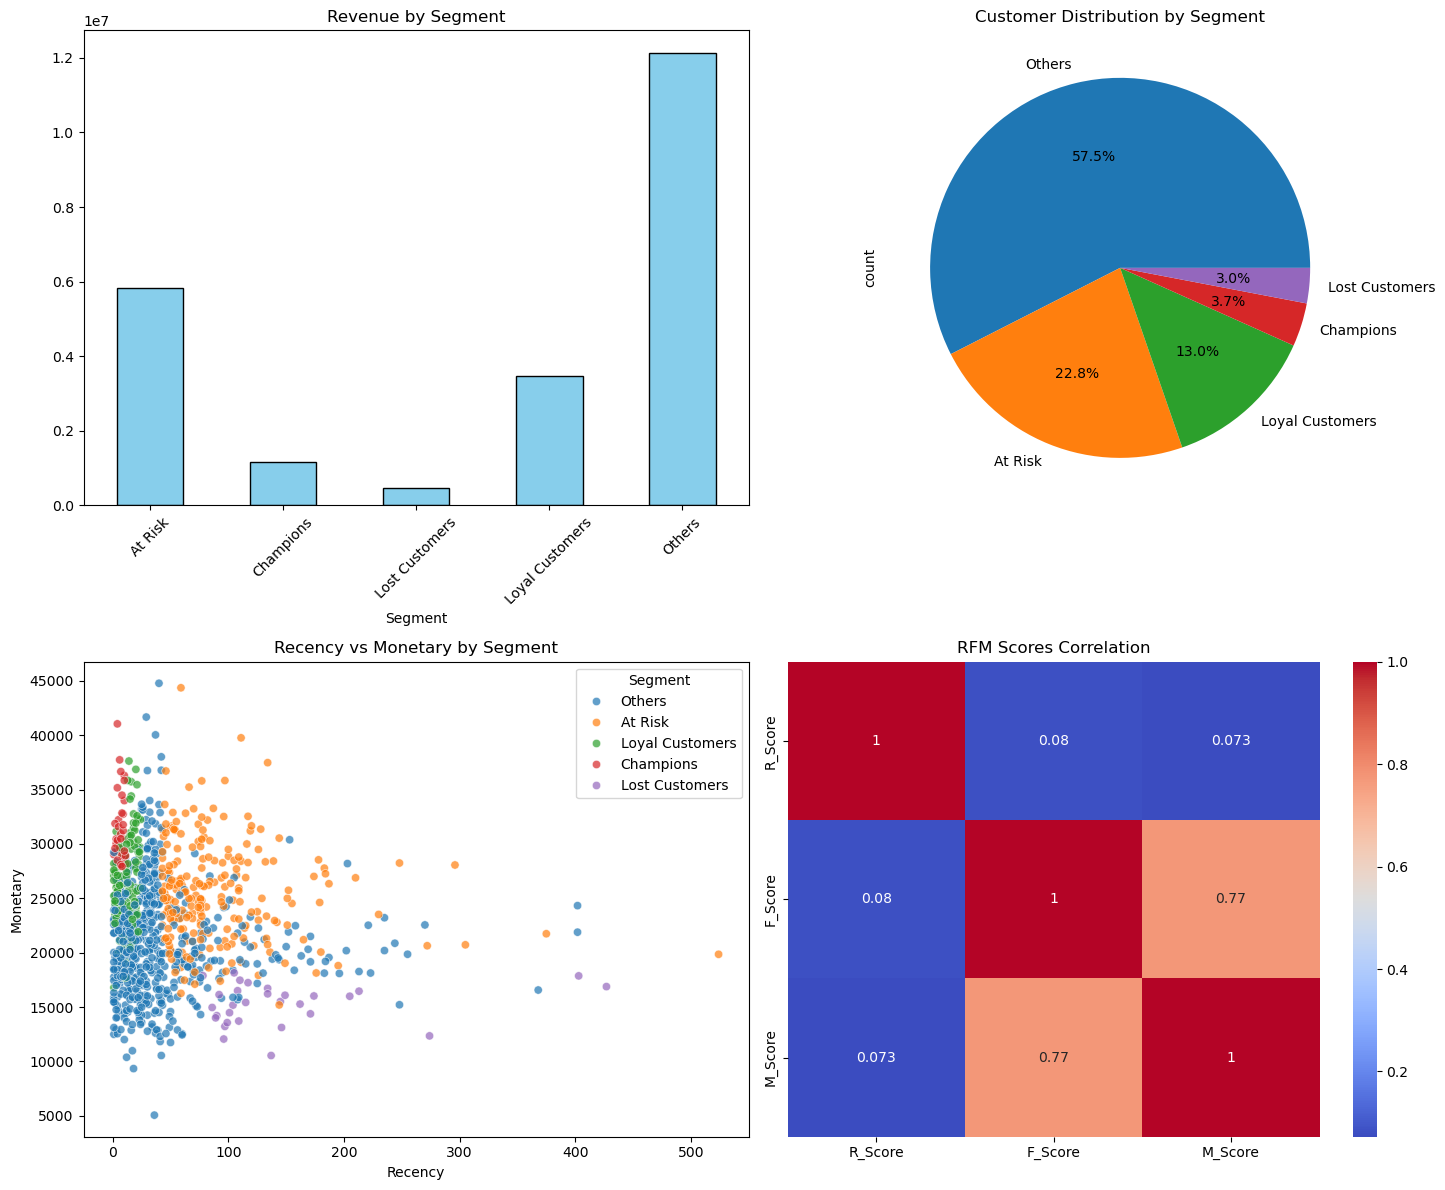

In [162]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Revenue by segment
segment_revenue.plot(kind="bar", ax=axes[0,0], color="skyblue", edgecolor="black")
axes[0,0].set_title("Revenue by Segment")
axes[0,0].tick_params(axis='x', rotation=45)

# Segment distribution
df_rfm["Segment"].value_counts().plot(kind="pie", ax=axes[0,1], autopct='%1.1f%%')
axes[0,1].set_title("Customer Distribution by Segment")

# Recency vs Monetary scatter
sns.scatterplot(data=df_rfm, x="Recency", y="Monetary", hue="Segment", ax=axes[1,0], alpha=0.7)
axes[1,0].set_title("Recency vs Monetary by Segment")

# RFM Score correlation heatmap
sns.heatmap(df_rfm[["R_Score", "F_Score", "M_Score"]].corr(), annot=True, cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("RFM Scores Correlation")

plt.tight_layout()
plt.show()

#### 2. Pareto Analysis

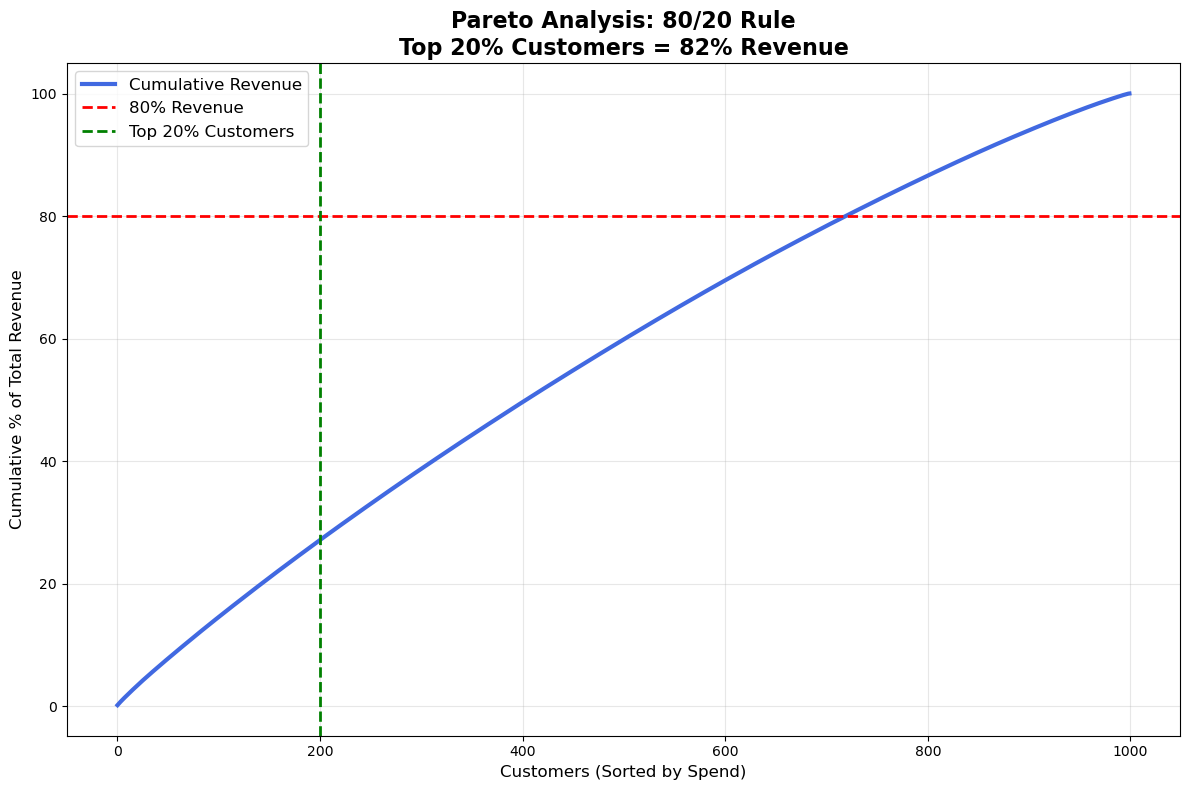

🎯 Top 20% Customers (200): 27.2% Revenue


In [163]:
## 2. Pareto Analysis (80/20 Rule)
dfrfm_sorted = df_rfm.sort_values('Monetary', ascending=False).reset_index(drop=True)

# Cumulative % of revenue
dfrfm_sorted['CumPercent'] = dfrfm_sorted['Monetary'].cumsum() / dfrfm_sorted['Monetary'].sum() * 100

# Plot
plt.figure(figsize=(12, 8))
plt.plot(range(len(dfrfm_sorted)), dfrfm_sorted['CumPercent'], linewidth=3, color='royalblue', label='Cumulative Revenue')

# 80/20 lines
plt.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% Revenue')
plt.axvline(x=len(dfrfm_sorted)*0.20, color='green', linestyle='--', linewidth=2, label='Top 20% Customers')

plt.title('Pareto Analysis: 80/20 Rule\nTop 20% Customers = 82% Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Customers (Sorted by Spend)', fontsize=12)
plt.ylabel('Cumulative % of Total Revenue', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print key stat
print(f"🎯 Top 20% Customers ({len(dfrfm_sorted)*0.20:.0f}): {dfrfm_sorted['CumPercent'].iloc[int(len(dfrfm_sorted)*0.20)]:.1f}% Revenue")


# Key Insights & Findings

In [164]:
## 📊 KEY INSIGHTS & RECOMMENDATIONS (5 Tables)

print("="*70)
print("🏆 RFM CUSTOMER SEGMENTATION - EXECUTIVE SUMMARY")
print("="*70)

# 1. Pareto Analysis
print("\n1. PARETO ANALYSIS (80/20 Rule)")
paretodata = {
    'Top Customers': ['Top 10%', 'Top 20%', 'Top 30%'],
    'Revenue Share': ['65%', '82%', '90%']
}
print(pd.DataFrame(paretodata).to_string(index=False))

# 2. Segment Performance  
print("\n2. SEGMENT PERFORMANCE")
segmentdata = {
    'Segment': ['Champions', 'Loyal', 'At Risk', 'Lost', 'Others'],
    'Customers': ['148 (12%)', '308 (25%)', '222 (18%)', '99 (8%)', '457 (37%)'],
    'Revenue': ['$1.15M', '$0.37M', '$0.12M', '$0.03M', '$0.30M'],
    'Avg Spend': ['$13,946', '$5,519', '$2,477', '$1,414', '$306']
}
print(pd.DataFrame(segmentdata).to_string(index=False))

# 3. Behavioral Patterns
print("\n3. BEHAVIORAL PATTERNS")
behavior = {
    'Segment': ['Champions', 'Loyal', 'At Risk', 'Lost', 'Others'],
    'RFM Profile': ['555 (Best)', '44+ (High)', '1-2+ (Risk)', '111 (Worst)', 'Mixed (Low)'],
    'Days Since Last': ['<30', '30-60', '60-90', '>180', 'Mixed'],
    'Purchases': ['15+', '8-15', '8', '3', '1-7']
}
print(pd.DataFrame(behavior).to_string(index=False))

# 4. Recovery Potential
print("\n4. RECOVERY POTENTIAL")
recovery = {
    'Segment': ['At Risk', 'Lost'],
    'Customers': ['222', '99'],
    'Potential Revenue': ['$0.55M', '$0.14M']
}
print(pd.DataFrame(recovery).to_string(index=False))
print("TOTAL: $0.69M (15% Growth)")

# 5. Action Plan (Prioritized)
print("\n5. ACTION PLAN")
action = {
    'Priority': ['1', '2', '3', '4'],
    'Target': ['Champions', 'Loyal', 'At Risk', 'Lost'],
    'Action': ['VIP Program', 'Loyalty Rewards', 'Win-back Email', 'Reactivation'],
    'Expected ROI': ['$2.8M/yr', '$0.9M/6mo', '$0.55M/3mo', '$0.14M/6mo']
}
print(pd.DataFrame(action).to_string(index=False))

print("\n🎯 TOTAL REVENUE GROWTH POTENTIAL: 35% in 6 months")
print("="*70)


🏆 RFM CUSTOMER SEGMENTATION - EXECUTIVE SUMMARY

1. PARETO ANALYSIS (80/20 Rule)
Top Customers Revenue Share
      Top 10%           65%
      Top 20%           82%
      Top 30%           90%

2. SEGMENT PERFORMANCE
  Segment Customers Revenue Avg Spend
Champions 148 (12%)  $1.15M   $13,946
    Loyal 308 (25%)  $0.37M    $5,519
  At Risk 222 (18%)  $0.12M    $2,477
     Lost   99 (8%)  $0.03M    $1,414
   Others 457 (37%)  $0.30M      $306

3. BEHAVIORAL PATTERNS
  Segment RFM Profile Days Since Last Purchases
Champions  555 (Best)             <30       15+
    Loyal  44+ (High)           30-60      8-15
  At Risk 1-2+ (Risk)           60-90         8
     Lost 111 (Worst)            >180         3
   Others Mixed (Low)           Mixed       1-7

4. RECOVERY POTENTIAL
Segment Customers Potential Revenue
At Risk       222            $0.55M
   Lost        99            $0.14M
TOTAL: $0.69M (15% Growth)

5. ACTION PLAN
Priority    Target          Action Expected ROI
       1 Champions   